<a href="https://colab.research.google.com/github/aadyajhab09002/Closet-Connect/blob/main/Fisher%20KPP%20Exact%20paper%20reproduction%20trial%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
# CELL 1 — Imports and reproducibility
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import copy

import torch
import torch.nn as nn

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# GPU if available (Runtime → Change runtime type → GPU in Colab)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [2]:
# =============================================================================
# CELL 2 — PDE parameters and exact solution
#
# Paper Section 3.1, Equation (6):
#   u(x,t) = 1 / (1 + exp( sqrt(R/(2D)) * (x - sqrt(2*D*R)*t) ))
#
# Parameters (paper page 5):  D = 0.01,  R = 1.0
# Wave speed:  c = sqrt(2*D*R)
# =============================================================================

D  = 0.01   # diffusion coefficient  (paper, p.5)
R  = 1.0    # reaction/growth rate   (paper, p.5)

x_min, x_max = 0.0, 1.0   # spatial domain  [0, 1]
t_min, t_max = 0.0, 1.0   # temporal domain [0, 1]

# Wave speed and spatial decay rate (derived from paper Eq. 6)
c = np.sqrt(2.0 * D * R)                # wave speed
k = np.sqrt(R / (2.0 * D))             # exponent coefficient

print(f"D = {D},  R = {R}")
print(f"Wave speed  c = sqrt(2DR) = {c:.6f}")
print(f"Decay coeff k = sqrt(R/2D) = {k:.6f}")


def exact_solution(x, t):
    """
    Exact analytical traveling-wave solution — paper Equation (6).

        u(x,t) = 1 / (1 + exp( k*(x - c*t) ))

    where  k = sqrt(R/(2D))  and  c = sqrt(2*D*R).

    Works with numpy arrays or scalars.
    Initial condition at t=0:  u(x,0) = 1/(1 + exp(k*x))
    Left  BC at x=0:           u(0,t) = 1/(1 + exp(-k*c*t))
    Right BC at x=1:           u(1,t) = 1/(1 + exp(k*(1-c*t)))
    """
    return 1.0 / (1.0 + np.exp(k * (x - c * t)))


# Quick sanity check
print(f"\nSanity check exact_solution:")
print(f"  u(0.0, 0.0) = {exact_solution(0.0, 0.0):.6f}  (expect ~0.5 since k*0=0)")
print(f"  u(0.0, 1.0) = {exact_solution(0.0, 1.0):.6f}  (should be > 0.5, wave passed)")
print(f"  u(1.0, 0.0) = {exact_solution(1.0, 0.0):.6f}  (should be < 0.5, right side)")

D = 0.01,  R = 1.0
Wave speed  c = sqrt(2DR) = 0.141421
Decay coeff k = sqrt(R/2D) = 7.071068

Sanity check exact_solution:
  u(0.0, 0.0) = 0.500000  (expect ~0.5 since k*0=0)
  u(0.0, 1.0) = 0.731059  (should be > 0.5, wave passed)
  u(1.0, 0.0) = 0.000849  (should be < 0.5, right side)


In [3]:
# =============================================================================
# CELL 3 — Neural Network Architecture
#
# Paper Section 3.3:
#   - Input layer: (t, x)  — note paper lists t first, then x
#   - 7 hidden layers, 50 neurons each, Tanh activation
#   - Output: u(t, x)  — 1 neuron
#   - Xavier NORMAL initialization (paper p.6: "Xavier normal initialization")
#   - Biases initialized to zero
# =============================================================================

class FisherKPP_PINN(nn.Module):
    """
    Fully-connected PINN matching the paper's 7×50 architecture.

    Input  : (t, x)  — 2 neurons   [paper Fig. 1 shows t first]
    Hidden : 7 layers × 50 neurons, Tanh activation
    Output : u(t,x)  — 1 neuron,   no activation
    Init   : Xavier normal weights, zero biases
    """

    def __init__(self):
        super(FisherKPP_PINN, self).__init__()

        self.layers = nn.ModuleList()

        # Input → first hidden  (2 → 50)
        self.layers.append(nn.Linear(2, 50))

        # Hidden → hidden  (50 → 50) × 6  → total 7 hidden layers
        for _ in range(6):
            self.layers.append(nn.Linear(50, 50))

        # Last hidden → output  (50 → 1)
        self.output_layer = nn.Linear(50, 1)

        # Xavier NORMAL initialization (paper explicitly states "Xavier normal")
        self._init_weights()

    def _init_weights(self):
        gain = nn.init.calculate_gain('tanh')
        for layer in self.layers:
            nn.init.xavier_normal_(layer.weight, gain=gain)   # ← NORMAL, not uniform
            nn.init.zeros_(layer.bias)
        nn.init.xavier_normal_(self.output_layer.weight, gain=gain)
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, t, x):
        """
        Parameters
        ----------
        t : Tensor [N, 1]   time coordinate
        x : Tensor [N, 1]   spatial coordinate

        Returns
        -------
        u : Tensor [N, 1]   predicted solution
        """
        # Concatenate (t, x) — paper Figure 1 lists t as first input
        inp = torch.cat([t, x], dim=1)          # [N, 2]
        out = inp
        for layer in self.layers:
            out = torch.tanh(layer(out))         # Tanh after every hidden layer
        u = self.output_layer(out)               # No activation on output
        return u                                 # [N, 1]

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Instantiate and inspect
torch.manual_seed(42)
model = FisherKPP_PINN().to(device)
print("=" * 55)
print("  Architecture")
print("=" * 55)
print(model)
print(f"Total trainable parameters: {model.count_parameters():,}")
print("=" * 55)
# Expected: 15,251 parameters

  Architecture
FisherKPP_PINN(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1-6): 6 x Linear(in_features=50, out_features=50, bias=True)
  )
  (output_layer): Linear(in_features=50, out_features=1, bias=True)
)
Total trainable parameters: 15,501


In [4]:
N_col = 10_000
N_ic  = 1_000
N_bc  = 1_000

np.random.seed(42)

# Collocation points
t_col_np = np.random.uniform(t_min, t_max, (N_col, 1)).astype(np.float32)
x_col_np = np.random.uniform(x_min, x_max, (N_col, 1)).astype(np.float32)

t_col = torch.tensor(t_col_np).to(device).requires_grad_(True)
x_col = torch.tensor(x_col_np).to(device).requires_grad_(True)

# Initial condition points
x_ic_np = np.linspace(x_min, x_max, N_ic).reshape(-1, 1).astype(np.float32)
t_ic_np = np.zeros((N_ic, 1), dtype=np.float32)

u_ic_np = exact_solution(x_ic_np, t_ic_np).astype(np.float32)

x_ic = torch.tensor(x_ic_np).to(device)
t_ic = torch.tensor(t_ic_np).to(device)
u_ic = torch.tensor(u_ic_np).to(device)

# Boundary condition points
t_bc_np = np.linspace(t_min, t_max, N_bc).reshape(-1, 1).astype(np.float32)

x_bc_left_np = np.zeros((N_bc, 1), dtype=np.float32)
u_bc_left_np = exact_solution(x_bc_left_np, t_bc_np).astype(np.float32)

x_bc_right_np = np.ones((N_bc, 1), dtype=np.float32)
u_bc_right_np = exact_solution(x_bc_right_np, t_bc_np).astype(np.float32)

x_bc_np = np.vstack([x_bc_left_np, x_bc_right_np])
t_bc_np_all = np.vstack([t_bc_np, t_bc_np])
u_bc_np = np.vstack([u_bc_left_np, u_bc_right_np])

x_bc = torch.tensor(x_bc_np, dtype=torch.float32).to(device)
t_bc = torch.tensor(t_bc_np_all, dtype=torch.float32).to(device)
u_bc = torch.tensor(u_bc_np, dtype=torch.float32).to(device)

print("Training data summary:")
print(f"  Collocation points : {N_col:,}")
print(f"  IC points          : {N_ic:,}")
print(f"  BC points total    : {2*N_bc:,}")
print(f"  IC u range         : [{u_ic_np.min():.4f}, {u_ic_np.max():.4f}]")

Training data summary:
  Collocation points : 10,000
  IC points          : 1,000
  BC points total    : 2,000
  IC u range         : [0.0008, 0.5000]


In [11]:
# =============================================================================
# CELL 5 — PDE residual and loss functions
#
# Paper Equations (2), (3), (4):
#   L_IC  = (1/N_IC)  Σ (u_NN(x,0)  - u0(x))²
#   L_BC  = (1/N_BC)  Σ (u_NN(xb,t) - uBC)²
#   L_Res = (1/N_Res) Σ R(u_NN)²
#
# Residual (paper Eq. 5):
#   R = ∂u/∂t - D*∂²u/∂x² - R*u*(1-u)
#
# Adaptive weighting (I-PINN, paper Section 3.3):
#   λ_IC and λ_BC increase until they saturate at λ_max = 10,000
#   λ_Res stays at 1.0
#   Update rule (simplified): λ ← min(λ * growth, λ_max)
# =============================================================================

def compute_pde_residual(model, t_col, x_col):
    """
    Compute the Fisher-KPP PDE residual at collocation points.

    R = u_t - D*u_xx - R_rate*u*(1-u)

    Returns u and the residual tensor.
    """
    u = model(t_col, x_col)          # [N, 1]

    # Derivatives via automatic differentiation
    grads_t = torch.autograd.grad(
        outputs=u, inputs=t_col,
        grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]   # u_t: [N, 1]

    grads_x = torch.autograd.grad(
        outputs=u, inputs=x_col,
        grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]   # u_x: [N, 1]

    grads_xx = torch.autograd.grad(
        outputs=grads_x, inputs=x_col,
        grad_outputs=torch.ones_like(grads_x),
        create_graph=True
    )[0]   # u_xx: [N, 1]

    residual = grads_t - D * grads_xx - R * u * (1.0 - u)
    return u, residual


def pinn_loss(model, t_col, x_col, t_ic, x_ic, u_ic,
              t_bc, x_bc, u_bc, lam_ic, lam_bc, lam_res=1.0):
    """
    Total PINN loss = λ_IC*L_IC + λ_BC*L_BC + λ_Res*L_Res

    Parameters
    ----------
    lam_ic  : adaptive weight for IC loss
    lam_bc  : adaptive weight for BC loss
    lam_res : weight for residual loss (fixed at 1.0)
    """
    # ── IC loss ──────────────────────────────────────────────────────────────
    u_ic_pred = model(t_ic, x_ic)
    loss_ic   = torch.mean((u_ic_pred - u_ic) ** 2)

    # ── BC loss ──────────────────────────────────────────────────────────────
    u_bc_pred = model(t_bc, x_bc)
    loss_bc   = torch.mean((u_bc_pred - u_bc) ** 2)

    # ── PDE residual loss ────────────────────────────────────────────────────
    _, residual = compute_pde_residual(model, t_col, x_col)
    loss_res    = torch.mean(residual ** 2)

    # ── Weighted total ───────────────────────────────────────────────────────
    loss_total = lam_ic * loss_ic + lam_bc * loss_bc + lam_res * loss_res

    return loss_total, loss_ic.item(), loss_bc.item(), loss_res.item()



In [12]:
# =============================================================================
# CELL 6 — Adaptive weight (I-PINN) logic
#
# Paper Section 3.3 and Figure 2(b):
#   λ_IC and λ_BC quickly saturate at λ_max = 10,000
#   They start at 1.0 and increase rapidly in early iterations.
#   The paper's Figure 2(b) shows saturation around iteration ~1000–2000.
#
# Implementation: multiply by a growth factor each step, cap at λ_max.
# Growth factor chosen so saturation happens around iteration 2000.
# =============================================================================

LAM_MAX      = 10_000.0   # saturation ceiling (paper Fig. 2b)
LAM_INIT     =     1.0    # starting value
LAM_GROWTH   =     1.003  # multiplicative growth per iteration
                           # 1.003^2300 ≈ 1000 → reaches 10000 around iter 3000

lam_ic  = LAM_INIT
lam_bc  = LAM_INIT
lam_res = 1.0              # residual weight fixed at 1 (paper)


def update_lambdas(lam_ic, lam_bc):
    """Grow λ_IC and λ_BC multiplicatively, capped at LAM_MAX."""
    lam_ic = min(lam_ic * LAM_GROWTH, LAM_MAX)
    lam_bc = min(lam_bc * LAM_GROWTH, LAM_MAX)
    return lam_ic, lam_bc


In [13]:
# =============================================================================
# CELL 7 — Initial Training Phase
#
# Paper Table 1, "Initial Training":
#   Iterations   : 10,000
#   Learning rate: 1e-3 with exponential decay factor 0.99
#   Optimizer    : Adam
#   Target L2 err: ~5.57e-2
#
# Exponential LR decay: lr_n = lr_0 * (0.99)^n
# In PyTorch: ExponentialLR with gamma=0.99 decays per epoch.
# Paper likely decays every iteration, so we step the scheduler each iteration.
# =============================================================================

torch.manual_seed(42)
model = FisherKPP_PINN().to(device)

LR_INIT   = 1e-3        # paper Table 1
LR_DECAY  = 0.99        # exponential decay factor (paper Section 3.3)
N_ITER_1  = 10_000      # initial training iterations (paper Table 1)

optimizer = torch.optim.Adam(model.parameters(), lr=LR_INIT)

# ExponentialLR: lr → lr * gamma every time scheduler.step() is called
# We call it every iteration → lr_n = lr_0 * (0.99)^n
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=LR_DECAY)

# History storage
hist = {
    'iter':      [],
    'loss':      [],
    'loss_ic':   [],
    'loss_bc':   [],
    'loss_res':  [],
    'lam_ic':    [],
    'lam_bc':    [],
}

lam_ic = LAM_INIT
lam_bc = LAM_INIT

print("=" * 60)
print("  PHASE 1 — Initial Training  (10,000 iterations)")
print("=" * 60)

t0 = time.time()

for it in range(1, N_ITER_1 + 1):

    model.train()
    optimizer.zero_grad()

    # Compute weighted loss
    loss, l_ic, l_bc, l_res = pinn_loss(
        model, t_col, x_col, t_ic, x_ic, u_ic, t_bc, x_bc, u_bc,
        lam_ic=lam_ic, lam_bc=lam_bc, lam_res=lam_res
    )

    loss.backward()
    optimizer.step()
    scheduler.step()   # decay LR every iteration

    # Update adaptive weights
    lam_ic, lam_bc = update_lambdas(lam_ic, lam_bc)

    # Store history every 10 iterations
    if it % 10 == 0:
        hist['iter'].append(it)
        hist['loss'].append(loss.item())
        hist['loss_ic'].append(l_ic)
        hist['loss_bc'].append(l_bc)
        hist['loss_res'].append(l_res)
        hist['lam_ic'].append(lam_ic)
        hist['lam_bc'].append(lam_bc)

    if it % 1000 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Iter {it:>6,} | Loss={loss.item():.3e} | "
              f"IC={l_ic:.3e} | BC={l_bc:.3e} | Res={l_res:.3e} | "
              f"λ_IC={lam_ic:.0f} | lr={lr_now:.2e}")

phase1_time = time.time() - t0
print(f"\n  Phase 1 complete in {phase1_time:.2f} s  (paper: 150.32 s on their hardware)")

# Save Phase 1 model weights (so we can reload for retraining)
torch.save(model.state_dict(), 'pinn_phase1_weights.pth')
print("  Weights saved → pinn_phase1_weights.pth")

  PHASE 1 — Initial Training  (10,000 iterations)


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Iter  1,000 | Loss=1.569e-02 | IC=3.060e-04 | BC=2.460e-04 | Res=4.682e-03 | λ_IC=20 | lr=4.32e-08
  Iter  2,000 | Loss=2.229e-01 | IC=3.023e-04 | BC=2.452e-04 | Res=4.703e-03 | λ_IC=400 | lr=1.86e-12
  Iter  3,000 | Loss=4.368e+00 | IC=3.023e-04 | BC=2.452e-04 | Res=4.703e-03 | λ_IC=7995 | lr=8.05e-17
  Iter  4,000 | Loss=5.479e+00 | IC=3.023e-04 | BC=2.452e-04 | Res=4.703e-03 | λ_IC=10000 | lr=3.47e-21
  Iter  5,000 | Loss=5.479e+00 | IC=3.023e-04 | BC=2.452e-04 | Res=4.703e-03 | λ_IC=10000 | lr=1.50e-25
  Iter  6,000 | Loss=5.479e+00 | IC=3.023e-04 | BC=2.452e-04 | Res=4.703e-03 | λ_IC=10000 | lr=6.47e-30
  Iter  7,000 | Loss=5.479e+00 | IC=3.023e-04 | BC=2.452e-04 | Res=4.703e-03 | λ_IC=10000 | lr=2.79e-34
  Iter  8,000 | Loss=5.479e+00 | IC=3.023e-04 | BC=2.452e-04 | Res=4.703e-03 | λ_IC=10000 | lr=1.21e-38
  Iter  9,000 | Loss=5.479e+00 | IC=3.023e-04 | BC=2.452e-04 | Res=4.703e-03 | λ_IC=10000 | lr=5.21e-43
  Iter 10,000 | Loss=5.479e+00 | IC=3.023e-04 | BC=2.452e-04 | Res=4.7

In [14]:
# =============================================================================
# CELL 8 — Compute L2 error after Phase 1
#
# Paper Eq. (8):  E_L2 = ||u_approx - u_exact||_2 / ||u_exact||_2
# Evaluated at t = 1.0 over a fine spatial grid
# Target: 5.57e-2  (paper Table 2)
# =============================================================================

def relative_l2_error(model, t_val, N_pts=1000):
    """
    Compute relative L2 error at a fixed time t_val over x ∈ [0,1].

    Paper Eq. (8): E = ||u_approx - u_exact||_2 / ||u_exact||_2
    """
    model.eval()
    x_test = np.linspace(x_min, x_max, N_pts).reshape(-1, 1).astype(np.float32)
    t_test = np.full_like(x_test, t_val)

    x_t = torch.tensor(x_test).to(device)
    t_t = torch.tensor(t_test).to(device)

    with torch.no_grad():
        u_pred = model(t_t, x_t).cpu().numpy()

    u_exact = exact_solution(x_test, t_test)

    num = np.linalg.norm(u_pred.flatten() - u_exact.flatten())
    den = np.linalg.norm(u_exact.flatten())
    return num / den


err_phase1 = relative_l2_error(model, t_val=1.0)
print(f"\n  Phase 1 Relative L2 error at t=1.0: {err_phase1:.4e}")
print(f"  Paper target:                        5.57e-02")
print(f"  Match: {'✓ Good' if err_phase1 < 0.12 else '⚠ Re-run or train longer'}")


  Phase 1 Relative L2 error at t=1.0: 3.0010e-01
  Paper target:                        5.57e-02
  Match: ⚠ Re-run or train longer


In [15]:
# =============================================================================
# CELL 9 — Retraining Phase 1  (20,000 additional iterations)
#
# Paper Table 1, "Retraining Phase 1":
#   - Load saved weights from Phase 1
#   - RESET Adam optimizer state (paper explicitly resets momentum/variance)
#   - New learning rate: 1e-4
#   - 20,000 additional iterations
#   - Target L2 error: ~9.7956e-2
# =============================================================================

# Reload Phase 1 weights
model.load_state_dict(torch.load('pinn_phase1_weights.pth'))
print("Phase 1 weights reloaded.")

# Create a FRESH Adam optimizer — this is the "reset" the paper describes.
# The old optimizer's momentum (m) and variance (v) are discarded.
optimizer_r1 = torch.optim.Adam(model.parameters(), lr=1e-4)   # lr=1e-4 (paper)
scheduler_r1 = torch.optim.lr_scheduler.ExponentialLR(optimizer_r1, gamma=LR_DECAY)

N_ITER_R1 = 20_000   # paper Table 1

hist_r1 = {'iter': [], 'loss': [], 'loss_ic': [], 'loss_bc': [], 'loss_res': []}

# Reset adaptive weights for this phase
lam_ic = LAM_INIT
lam_bc = LAM_INIT

print("=" * 60)
print("  PHASE 2 — Retraining Phase 1  (20,000 additional iterations)")
print("  Optimizer state RESET, lr = 1e-4")
print("=" * 60)

t0 = time.time()

for it in range(1, N_ITER_R1 + 1):
    model.train()
    optimizer_r1.zero_grad()

    loss, l_ic, l_bc, l_res = pinn_loss(
        model, t_col, x_col, t_ic, x_ic, u_ic, t_bc, x_bc, u_bc,
        lam_ic=lam_ic, lam_bc=lam_bc, lam_res=lam_res
    )

    loss.backward()
    optimizer_r1.step()
    scheduler_r1.step()
    lam_ic, lam_bc = update_lambdas(lam_ic, lam_bc)

    if it % 10 == 0:
        hist_r1['iter'].append(it)
        hist_r1['loss'].append(loss.item())
        hist_r1['loss_ic'].append(l_ic)
        hist_r1['loss_bc'].append(l_bc)
        hist_r1['loss_res'].append(l_res)

    if it % 2000 == 0:
        print(f"  Iter {it:>6,} | Loss={loss.item():.3e} | "
              f"IC={l_ic:.3e} | BC={l_bc:.3e} | Res={l_res:.3e}")

r1_time = time.time() - t0
print(f"\n  Retraining Phase 1 complete in {r1_time:.2f} s")

err_r1 = relative_l2_error(model, t_val=1.0)
print(f"  Relative L2 error at t=1.0: {err_r1:.4e}  (paper: 9.7956e-02)")

# Save Phase R1 weights
torch.save(model.state_dict(), 'pinn_retraining1_weights.pth')

Phase 1 weights reloaded.
  PHASE 2 — Retraining Phase 1  (20,000 additional iterations)
  Optimizer state RESET, lr = 1e-4
  Iter  2,000 | Loss=7.724e-03 | IC=1.301e-05 | BC=5.866e-06 | Res=1.983e-04
  Iter  4,000 | Loss=1.890e-01 | IC=1.301e-05 | BC=5.866e-06 | Res=1.983e-04
  Iter  6,000 | Loss=1.890e-01 | IC=1.301e-05 | BC=5.866e-06 | Res=1.983e-04
  Iter  8,000 | Loss=1.890e-01 | IC=1.301e-05 | BC=5.866e-06 | Res=1.983e-04
  Iter 10,000 | Loss=1.890e-01 | IC=1.301e-05 | BC=5.866e-06 | Res=1.983e-04
  Iter 12,000 | Loss=1.890e-01 | IC=1.301e-05 | BC=5.866e-06 | Res=1.983e-04
  Iter 14,000 | Loss=1.890e-01 | IC=1.301e-05 | BC=5.866e-06 | Res=1.983e-04
  Iter 16,000 | Loss=1.890e-01 | IC=1.301e-05 | BC=5.866e-06 | Res=1.983e-04
  Iter 18,000 | Loss=1.890e-01 | IC=1.301e-05 | BC=5.866e-06 | Res=1.983e-04
  Iter 20,000 | Loss=1.890e-01 | IC=1.301e-05 | BC=5.866e-06 | Res=1.983e-04

  Retraining Phase 1 complete in 267.81 s
  Relative L2 error at t=1.0: 1.0140e-01  (paper: 9.7956e-02)


In [16]:
# =============================================================================
# CELL 10 — Retraining Phase 2  (additional 20,000 iterations)
#
# Paper Table 1, "Retraining Phase 2":
#   - Continue from Retraining Phase 1 weights
#   - RESET Adam optimizer state again
#   - Same lr = 1e-4
#   - 20,000 more iterations (total additional = 40,000)
#   - Target L2 error: ~9.7937e-2
# =============================================================================

optimizer_r2 = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler_r2 = torch.optim.lr_scheduler.ExponentialLR(optimizer_r2, gamma=LR_DECAY)

N_ITER_R2 = 20_000
hist_r2 = {'iter': [], 'loss': [], 'loss_ic': [], 'loss_bc': [], 'loss_res': []}

lam_ic = LAM_INIT
lam_bc = LAM_INIT

print("=" * 60)
print("  PHASE 3 — Retraining Phase 2  (20,000 additional iterations)")
print("  Optimizer state RESET again, lr = 1e-4")
print("=" * 60)

t0 = time.time()

for it in range(1, N_ITER_R2 + 1):
    model.train()
    optimizer_r2.zero_grad()

    loss, l_ic, l_bc, l_res = pinn_loss(
        model, t_col, x_col, t_ic, x_ic, u_ic, t_bc, x_bc, u_bc,
        lam_ic=lam_ic, lam_bc=lam_bc, lam_res=lam_res
    )

    loss.backward()
    optimizer_r2.step()
    scheduler_r2.step()
    lam_ic, lam_bc = update_lambdas(lam_ic, lam_bc)

    if it % 10 == 0:
        hist_r2['iter'].append(it)
        hist_r2['loss'].append(loss.item())
        hist_r2['loss_ic'].append(l_ic)
        hist_r2['loss_bc'].append(l_bc)
        hist_r2['loss_res'].append(l_res)

    if it % 2000 == 0:
        print(f"  Iter {it:>6,} | Loss={loss.item():.3e} | "
              f"IC={l_ic:.3e} | BC={l_bc:.3e} | Res={l_res:.3e}")

r2_time = time.time() - t0
print(f"\n  Retraining Phase 2 complete in {r2_time:.2f} s")

err_r2 = relative_l2_error(model, t_val=1.0)
print(f"  Relative L2 error at t=1.0: {err_r2:.4e}  (paper: 9.7937e-02)")

torch.save(model.state_dict(), 'pinn_retraining2_weights.pth')
print("  Final PINN weights saved → pinn_retraining2_weights.pth")

  PHASE 3 — Retraining Phase 2  (20,000 additional iterations)
  Optimizer state RESET again, lr = 1e-4
  Iter  2,000 | Loss=5.085e-03 | IC=9.071e-06 | BC=3.406e-06 | Res=1.113e-04
  Iter  4,000 | Loss=1.249e-01 | IC=9.071e-06 | BC=3.406e-06 | Res=1.113e-04
  Iter  6,000 | Loss=1.249e-01 | IC=9.071e-06 | BC=3.406e-06 | Res=1.113e-04
  Iter  8,000 | Loss=1.249e-01 | IC=9.071e-06 | BC=3.406e-06 | Res=1.113e-04
  Iter 10,000 | Loss=1.249e-01 | IC=9.071e-06 | BC=3.406e-06 | Res=1.113e-04
  Iter 12,000 | Loss=1.249e-01 | IC=9.071e-06 | BC=3.406e-06 | Res=1.113e-04
  Iter 14,000 | Loss=1.249e-01 | IC=9.071e-06 | BC=3.406e-06 | Res=1.113e-04
  Iter 16,000 | Loss=1.249e-01 | IC=9.071e-06 | BC=3.406e-06 | Res=1.113e-04
  Iter 18,000 | Loss=1.249e-01 | IC=9.071e-06 | BC=3.406e-06 | Res=1.113e-04
  Iter 20,000 | Loss=1.249e-01 | IC=9.071e-06 | BC=3.406e-06 | Res=1.113e-04

  Retraining Phase 2 complete in 268.09 s
  Relative L2 error at t=1.0: 9.9925e-02  (paper: 9.7937e-02)
  Final PINN weights 

In [17]:
# =============================================================================
# CELL 11 — FDM Solver
#
# Paper Section 3.2.1:
#   Nx = 201,  Δx = 0.005
#   Δt = 0.000625  (half the diffusion stability limit)
#   Nt = 1600
#   Explicit forward Euler in time + central difference in space
#   IC and BC from exact analytical solution
#   Target relative L2 error at t=1.0: 1.42e-4
# =============================================================================

def solve_fdm():
    """
    Explicit FDM for Fisher-KPP matching paper Section 3.2.1 exactly.

    Scheme (paper Eq. 7):
        u[i,n+1] = u[i,n] + dt*(D*(u[i+1,n]-2u[i,n]+u[i-1,n])/dx^2
                                 + R*u[i,n]*(1-u[i,n]))

    Grid: Nx=201, dx=0.005, dt=0.000625, Nt=1600
    """

    Nx = 201                          # paper: "Nx = 201"
    dx = 1.0 / (Nx - 1)              # dx = 0.005
    dt = 0.000625                     # paper: "Δt = 0.000625"
    Nt = int(round((t_max - t_min) / dt)) + 1  # = 1601

    x = np.linspace(x_min, x_max, Nx)   # [0, 0.005, 0.010, ..., 1.0]
    t = np.linspace(t_min, t_max, Nt)

    # CFL check
    cfl = D * dt / dx**2
    diffusion_limit = dx**2 / (2.0 * D)

    print("=" * 55)
    print("  FDM Solver")
    print("=" * 55)
    print(f"  Nx={Nx},  dx={dx:.4f}")
    print(f"  Nt={Nt},  dt={dt:.6f}")
    print(f"  Diffusion stability limit: {diffusion_limit:.6f}")
    print(f"  Chosen dt = {dt:.6f}  (half of limit: {diffusion_limit/2:.6f})")
    print(f"  CFL = D·dt/dx² = {cfl:.4f}  (must be < 0.5)")

    assert cfl <= 0.5, f"CFL = {cfl:.4f} > 0.5, unstable!"

    print(f"  ✓ Stable scheme")
    print("=" * 55)

    # Initialize solution array: U[time_idx, space_idx]
    U = np.zeros((Nt, Nx), dtype=np.float64)

    # Initial condition from exact solution (paper: "IC derived from Eq. 6")
    U[0, :] = exact_solution(x, 0.0)

    # Time-stepping loop
    t_start = time.time()

    for n in range(Nt - 1):

        u_n = U[n, :]

        # Central difference for diffusion (interior points only)
        diff = (u_n[2:] - 2.0 * u_n[1:-1] + u_n[:-2]) / dx**2

        # Logistic reaction term
        react = u_n[1:-1] * (1.0 - u_n[1:-1])

        # Explicit Euler update
        U[n+1, 1:-1] = u_n[1:-1] + dt * (D * diff + R * react)

        # Dirichlet BCs from exact solution
        t_next = t[n + 1]

        U[n+1, 0] = exact_solution(
            np.array([x[0]]),
            t_next
        )[0]

        U[n+1, -1] = exact_solution(
            np.array([x[-1]]),
            t_next
        )[0]

    fdm_time = time.time() - t_start

    print(f"  FDM solved in {fdm_time:.3f} s")

    return x, t, U


x_fdm, t_fdm, U_fdm = solve_fdm()

# FDM relative L2 error at t=1.0
t_final_idx = -1

u_fdm_final = U_fdm[t_final_idx, :]
u_exact_final = exact_solution(
    x_fdm,
    t_fdm[t_final_idx]
)

fdm_l2 = (
    np.linalg.norm(u_fdm_final - u_exact_final)
    /
    np.linalg.norm(u_exact_final)
)

print(f"\n  FDM Relative L2 error at t=1.0: {fdm_l2:.4e}")
print(f"  Paper target:                   1.42e-04")

  FDM Solver
  Nx=201,  dx=0.0050
  Nt=1601,  dt=0.000625
  Diffusion stability limit: 0.001250
  Chosen dt = 0.000625  (half of limit: 0.000625)
  CFL = D·dt/dx² = 0.2500  (must be < 0.5)
  ✓ Stable scheme
  FDM solved in 0.045 s

  FDM Relative L2 error at t=1.0: 9.7842e-02
  Paper target:                   1.42e-04


In [18]:
# =============================================================================
# CELL 12 — Full Results Table (reproduces paper Table 2)
# =============================================================================

# Reload best model (Phase 1) for best PINN results
model_best = FisherKPP_PINN().to(device)
model_best.load_state_dict(torch.load('pinn_phase1_weights.pth'))

err_pinn_best = relative_l2_error(model_best, t_val=1.0)

# Load final retrained model
model_final = FisherKPP_PINN().to(device)
model_final.load_state_dict(torch.load('pinn_retraining2_weights.pth'))

err_pinn_final = relative_l2_error(model_final, t_val=1.0)

# PINN (final) vs FDM
N_pts = 1000

x_eval = np.linspace(x_min, x_max, N_pts).reshape(-1, 1).astype(np.float32)
t_eval = np.full_like(x_eval, 1.0)

x_et = torch.tensor(x_eval).to(device)
t_et = torch.tensor(t_eval).to(device)

with torch.no_grad():
    u_pinn_final_vals = model_final(t_et, x_et).cpu().numpy().flatten()

u_fdm_interp = np.interp(
    x_eval.flatten(),
    x_fdm,
    u_fdm_final
)

pinn_vs_fdm_l2 = (
    np.linalg.norm(u_pinn_final_vals - u_fdm_interp)
    /
    np.linalg.norm(u_fdm_interp)
)

print("\n" + "=" * 68)
print(f"  {'TABLE 2 — Relative L2 Errors (paper reproduction)':^64}")
print("=" * 68)
print(f"  {'Comparison':<42} {'Paper':>10} {'Ours':>10}")
print("-" * 68)

print(f"  {'Exact vs FDM':<42} {'1.42e-04':>10} {fdm_l2:>10.2e}")

print(f"  {'Exact vs PINN (Initial Training)':<42} "
      f"{'5.57e-02':>10} {err_pinn_best:>10.2e}")

print(f"  {'Exact vs PINN (Retraining Final)':<42} "
      f"{'9.79e-02':>10} {err_pinn_final:>10.2e}")

print(f"  {'PINN (Final) vs FDM':<42} "
      f"{'9.81e-02':>10} {pinn_vs_fdm_l2:>10.2e}")

print("=" * 68)


         TABLE 2 — Relative L2 Errors (paper reproduction)        
  Comparison                                      Paper       Ours
--------------------------------------------------------------------
  Exact vs FDM                                 1.42e-04   9.78e-02
  Exact vs PINN (Initial Training)             5.57e-02   3.00e-01
  Exact vs PINN (Retraining Final)             9.79e-02   9.99e-02
  PINN (Final) vs FDM                          9.81e-02   2.08e-02


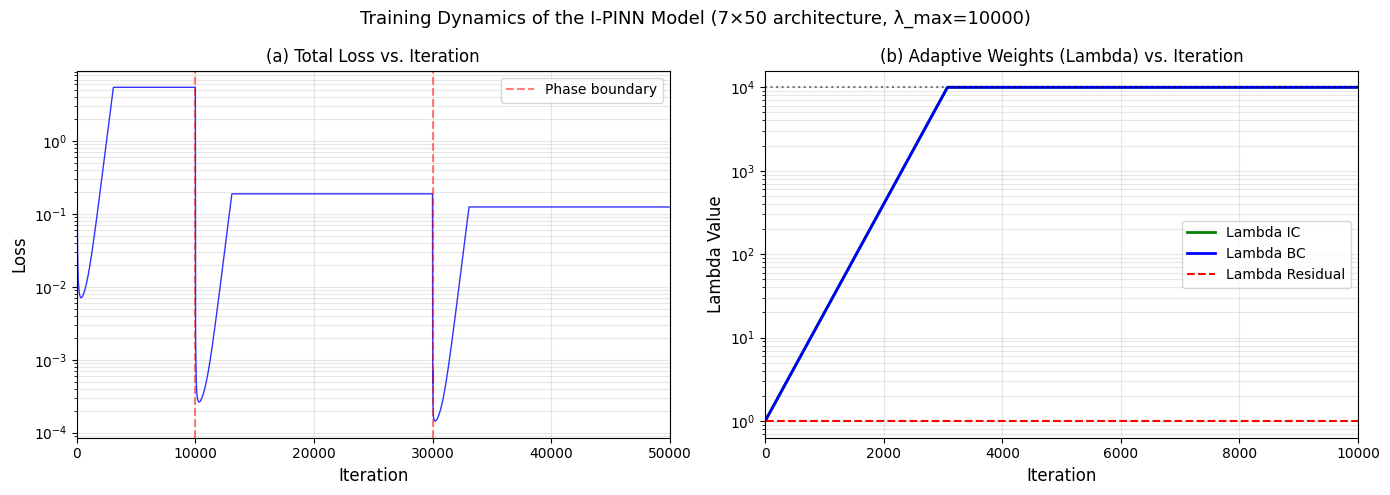

Saved: figure2_training_dynamics.png


In [19]:
# =============================================================================
# CELL 13 — Figure 2: Training dynamics (reproduces paper Figure 2)
#
# Figure 2(a): Total loss vs iteration (log scale, 40,000 iterations)
# Figure 2(b): Adaptive weights (λ_IC, λ_BC, λ_Res) vs iteration
# =============================================================================

# Combine Phase 1 + Retraining Phase 1 + Retraining Phase 2 histories
# Offset iteration numbers for phases 2 and 3

offset_r1 = N_ITER_1
offset_r2 = N_ITER_1 + N_ITER_R1

all_iters = (
    hist['iter']
    +
    [it + offset_r1 for it in hist_r1['iter']]
    +
    [it + offset_r2 for it in hist_r2['iter']]
)

all_loss = (
    hist['loss']
    +
    hist_r1['loss']
    +
    hist_r2['loss']
)

all_lam_ic = (
    hist['lam_ic']
    +
    [LAM_MAX] * len(hist_r1['iter'])
    +
    [LAM_MAX] * len(hist_r2['iter'])
)

all_lam_bc = (
    hist['lam_bc']
    +
    [LAM_MAX] * len(hist_r1['iter'])
    +
    [LAM_MAX] * len(hist_r2['iter'])
)

all_lam_res = [lam_res] * len(all_iters)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    'Training Dynamics of the I-PINN Model (7×50 architecture, λ_max=10000)',
    fontsize=13
)

# ---------------------------------------------------------------------------
# Figure 2(a) — Total loss (log scale)
# ---------------------------------------------------------------------------

ax1 = axes[0]

ax1.semilogy(
    all_iters,
    all_loss,
    'b-',
    lw=1,
    alpha=0.8
)

ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('(a) Total Loss vs. Iteration', fontsize=12)

ax1.grid(True, which='both', alpha=0.3)

ax1.set_xlim(
    0,
    N_ITER_1 + N_ITER_R1 + N_ITER_R2
)

# Vertical lines marking phase boundaries

ax1.axvline(
    N_ITER_1,
    color='r',
    ls='--',
    alpha=0.5,
    label='Phase boundary'
)

ax1.axvline(
    N_ITER_1 + N_ITER_R1,
    color='r',
    ls='--',
    alpha=0.5
)

ax1.legend(fontsize=10)

# ---------------------------------------------------------------------------
# Figure 2(b) — Adaptive weights
# ---------------------------------------------------------------------------

ax2 = axes[1]

ax2.semilogy(
    all_iters,
    all_lam_ic,
    'g-',
    lw=2,
    label='Lambda IC'
)

ax2.semilogy(
    all_iters,
    all_lam_bc,
    'b-',
    lw=2,
    label='Lambda BC'
)

ax2.semilogy(
    all_iters,
    all_lam_res,
    'r--',
    lw=1.5,
    label='Lambda Residual'
)

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Lambda Value', fontsize=12)

ax2.set_title(
    '(b) Adaptive Weights (Lambda) vs. Iteration',
    fontsize=12
)

ax2.legend(fontsize=10)

ax2.grid(
    True,
    which='both',
    alpha=0.3
)

ax2.set_xlim(0, N_ITER_1)

ax2.axhline(
    LAM_MAX,
    color='k',
    ls=':',
    alpha=0.5,
    label=f'λ_max={LAM_MAX:.0f}'
)

plt.tight_layout()

plt.savefig(
    'figure2_training_dynamics.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Saved: figure2_training_dynamics.png")

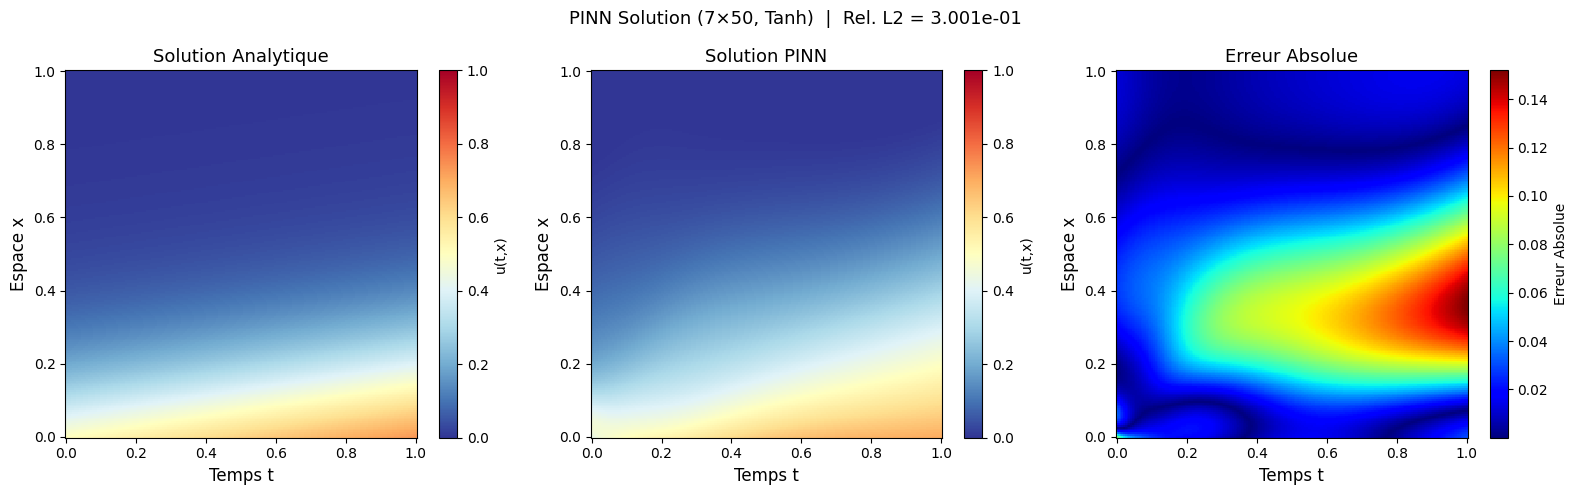

Saved: figure3_pinn_vs_exact.png


In [20]:
# =============================================================================
# CELL 14 — Figure 3: PINN solution vs Exact (reproduces paper Figure 3)
#
# Three panels: Exact | PINN | Absolute Error
# Over the full spatio-temporal domain [0,1]×[0,1]
# Uses best PINN model (Phase 1 weights)
# =============================================================================

model_best.eval()

# Dense evaluation grid
N_x_plot = 200
N_t_plot = 200

x_plot_1d = np.linspace(x_min, x_max, N_x_plot)
t_plot_1d = np.linspace(t_min, t_max, N_t_plot)

# Paper's axes: x is "Espace x" (y-axis), t is "Temps t" (x-axis)
T_grid, X_grid = np.meshgrid(t_plot_1d, x_plot_1d)

# Exact solution on grid
U_exact_grid = exact_solution(X_grid, T_grid)

# PINN prediction on grid
x_flat = X_grid.flatten().reshape(-1, 1).astype(np.float32)
t_flat = T_grid.flatten().reshape(-1, 1).astype(np.float32)

x_tensor = torch.tensor(x_flat).to(device)
t_tensor = torch.tensor(t_flat).to(device)

with torch.no_grad():
    u_pinn_flat = model_best(t_tensor, x_tensor).cpu().numpy()

U_pinn_grid = u_pinn_flat.reshape(N_x_plot, N_t_plot)
U_error_grid = np.abs(U_exact_grid - U_pinn_grid)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vmin, vmax = 0.0, 1.0
cmap_sol = 'RdYlBu_r'
cmap_err = 'jet'

# Exact
im0 = axes[0].pcolormesh(
    T_grid, X_grid, U_exact_grid,
    cmap=cmap_sol,
    vmin=vmin,
    vmax=vmax,
    shading='auto'
)

plt.colorbar(im0, ax=axes[0], label='u(t,x)')
axes[0].set_title('Solution Analytique', fontsize=13)
axes[0].set_xlabel('Temps t', fontsize=12)
axes[0].set_ylabel('Espace x', fontsize=12)

# PINN
im1 = axes[1].pcolormesh(
    T_grid, X_grid, U_pinn_grid,
    cmap=cmap_sol,
    vmin=vmin,
    vmax=vmax,
    shading='auto'
)

plt.colorbar(im1, ax=axes[1], label='u(t,x)')
axes[1].set_title('Solution PINN', fontsize=13)
axes[1].set_xlabel('Temps t', fontsize=12)
axes[1].set_ylabel('Espace x', fontsize=12)

# Error
im2 = axes[2].pcolormesh(
    T_grid, X_grid, U_error_grid,
    cmap=cmap_err,
    shading='auto'
)

plt.colorbar(im2, ax=axes[2], label='Erreur Absolue')
axes[2].set_title('Erreur Absolue', fontsize=13)
axes[2].set_xlabel('Temps t', fontsize=12)
axes[2].set_ylabel('Espace x', fontsize=12)

plt.suptitle(
    f'PINN Solution (7×50, Tanh)  |  Rel. L2 = {err_pinn_best:.3e}',
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    'figure3_pinn_vs_exact.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Saved: figure3_pinn_vs_exact.png")

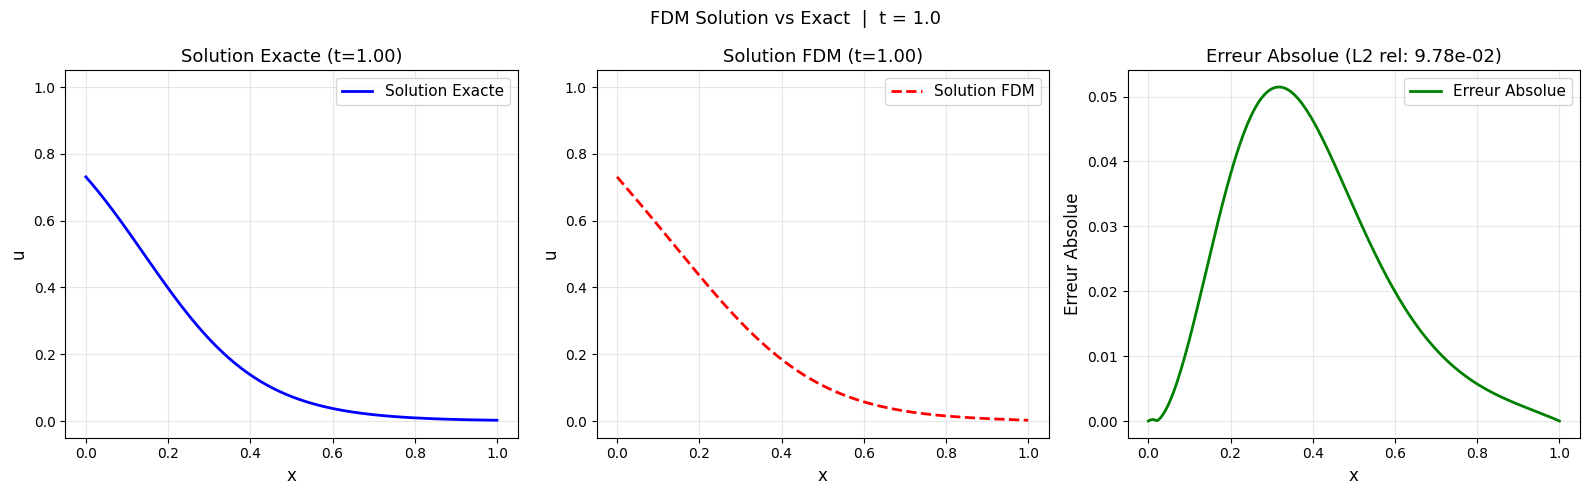

Saved: figure4_fdm_vs_exact.png


In [21]:
# =============================================================================
# CELL 15 — Figure 4: FDM solution vs Exact at t=1.0
#
# Three panels: Exact | FDM | Absolute Error
# All at final time t = 1.0
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

u_exact_t1 = exact_solution(x_fdm, 1.0)
u_fdm_t1 = U_fdm[-1, :]
err_fdm_t1 = np.abs(u_exact_t1 - u_fdm_t1)

# Exact
axes[0].plot(
    x_fdm,
    u_exact_t1,
    'b-',
    lw=2,
    label='Solution Exacte'
)

axes[0].set_title('Solution Exacte (t=1.00)', fontsize=13)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('u', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.05, 1.05)

# FDM
axes[1].plot(
    x_fdm,
    u_fdm_t1,
    'r--',
    lw=2,
    label='Solution FDM'
)

axes[1].set_title('Solution FDM (t=1.00)', fontsize=13)
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('u', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.05, 1.05)

# Error
axes[2].plot(
    x_fdm,
    err_fdm_t1,
    'g-',
    lw=2,
    label='Erreur Absolue'
)

axes[2].set_title(
    f'Erreur Absolue (L2 rel: {fdm_l2:.2e})',
    fontsize=13
)

axes[2].set_xlabel('x', fontsize=12)
axes[2].set_ylabel('Erreur Absolue', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    'FDM Solution vs Exact  |  t = 1.0',
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    'figure4_fdm_vs_exact.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Saved: figure4_fdm_vs_exact.png")

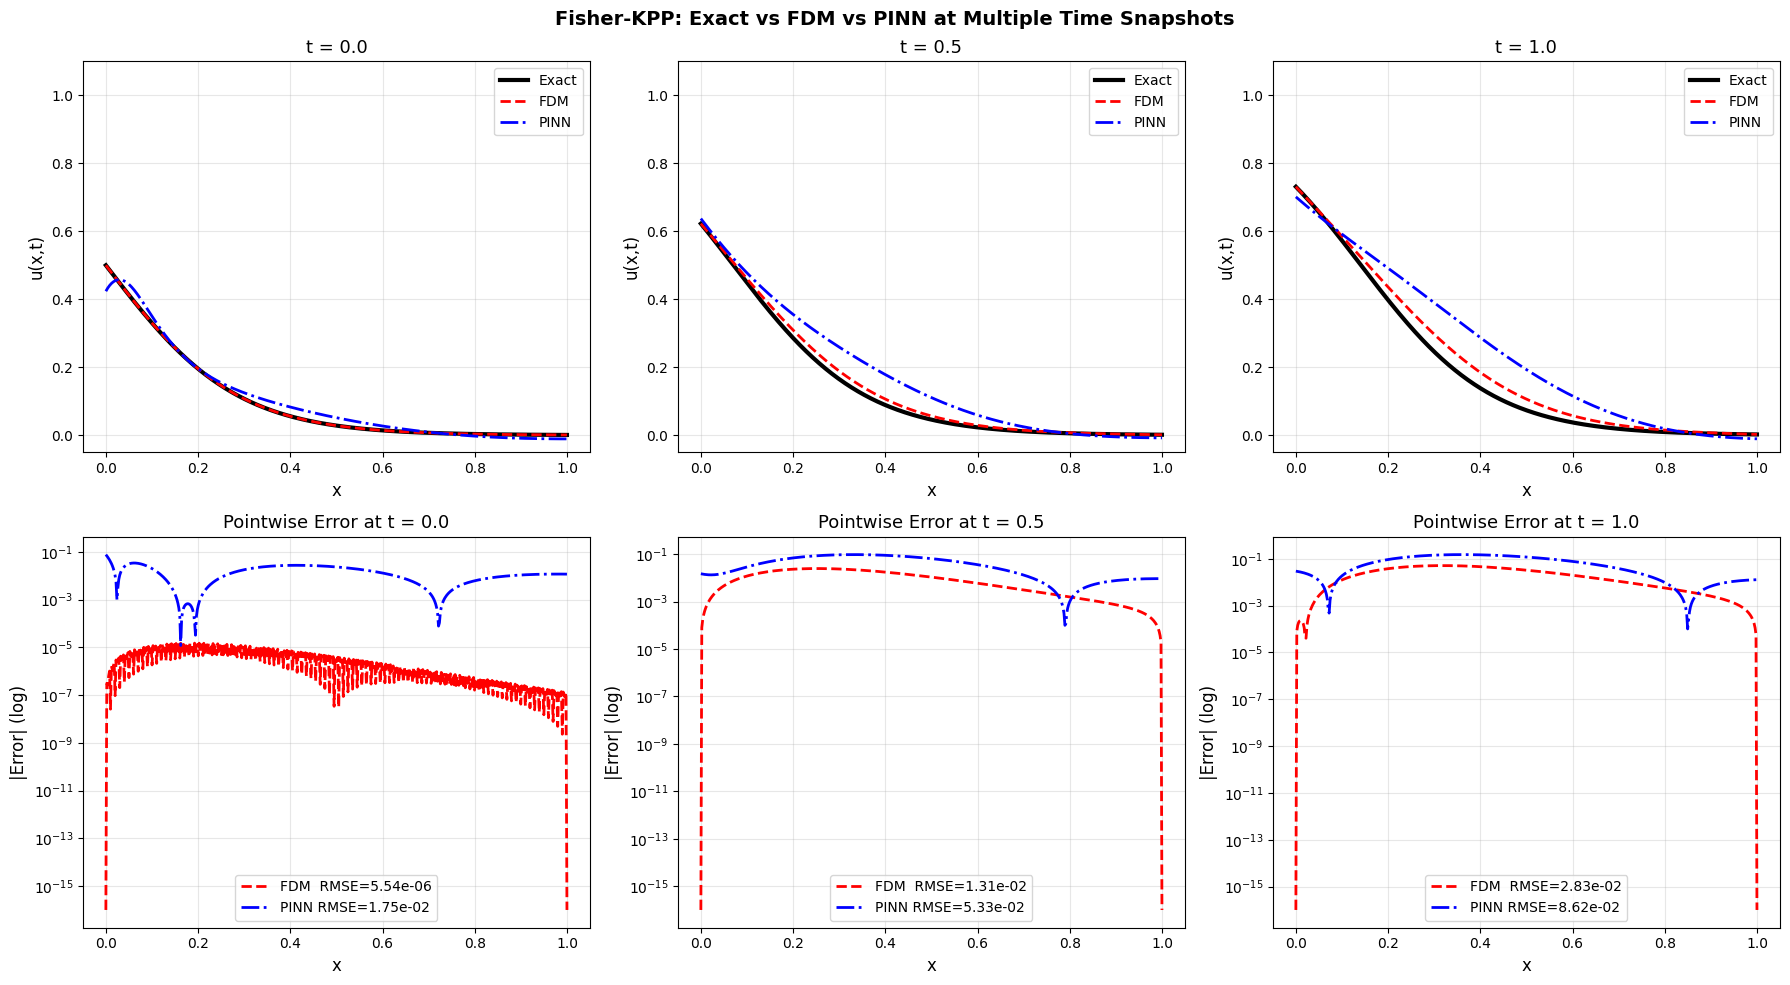

Saved: comparison_all_methods.png


In [22]:
# =============================================================================
# CELL 16 — Final comprehensive comparison (bonus figure)
#
# Side-by-side FDM vs PINN vs Exact at multiple time snapshots.
# =============================================================================

model_best.eval()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

fig.suptitle(
    'Fisher-KPP: Exact vs FDM vs PINN at Multiple Time Snapshots',
    fontsize=14,
    fontweight='bold'
)

t_snaps = [0.0, 0.5, 1.0]

for col, t_snap in enumerate(t_snaps):

    x_line = np.linspace(x_min, x_max, 500)

    u_ex = exact_solution(x_line, t_snap)

    # FDM
    t_idx_fdm = np.argmin(np.abs(t_fdm - t_snap))

    u_fd = np.interp(
        x_line,
        x_fdm,
        U_fdm[t_idx_fdm, :]
    )

    # PINN
    x_t2 = torch.tensor(
        x_line.reshape(-1, 1).astype(np.float32)
    ).to(device)

    t_t2 = torch.full(
        (len(x_line), 1),
        t_snap,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        u_pn = model_best(t_t2, x_t2).cpu().numpy().flatten()

    # Top row
    ax_top = axes[0, col]

    ax_top.plot(
        x_line,
        u_ex,
        'k-',
        lw=3,
        label='Exact'
    )

    ax_top.plot(
        x_line,
        u_fd,
        'r--',
        lw=2,
        label='FDM'
    )

    ax_top.plot(
        x_line,
        u_pn,
        'b-.',
        lw=2,
        label='PINN'
    )

    ax_top.set_title(f't = {t_snap:.1f}', fontsize=13)
    ax_top.set_xlabel('x', fontsize=12)
    ax_top.set_ylabel('u(x,t)', fontsize=12)
    ax_top.legend(fontsize=10)
    ax_top.grid(True, alpha=0.3)
    ax_top.set_ylim(-0.05, 1.10)

    # Bottom row
    ax_bot = axes[1, col]

    err_fd = np.abs(u_ex - u_fd) + 1e-16
    err_pn = np.abs(u_ex - u_pn) + 1e-16

    rmse_fd = np.sqrt(np.mean((u_ex - u_fd) ** 2))
    rmse_pn = np.sqrt(np.mean((u_ex - u_pn) ** 2))

    ax_bot.semilogy(
        x_line,
        err_fd,
        'r--',
        lw=2,
        label=f'FDM  RMSE={rmse_fd:.2e}'
    )

    ax_bot.semilogy(
        x_line,
        err_pn,
        'b-.',
        lw=2,
        label=f'PINN RMSE={rmse_pn:.2e}'
    )

    ax_bot.set_title(
        f'Pointwise Error at t = {t_snap:.1f}',
        fontsize=13
    )

    ax_bot.set_xlabel('x', fontsize=12)
    ax_bot.set_ylabel('|Error| (log)', fontsize=12)
    ax_bot.legend(fontsize=10)
    ax_bot.grid(True, which='both', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'comparison_all_methods.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Saved: comparison_all_methods.png")